<div class="alert alert-block alert-info">
Singapore Management University<br>
CS105 Statistical Thinking for Data Science, 2024/25 Term 2
</div>

# CS105 Group Project Submission (Part I)

-----
Provide your team details, including section, team number, team members, and the name of the dataset. 
Complete all of the following sections. For any part requiring code to derive your answers, please create a code cell immediately below your response and run the code.
To edit any markdown cell, double click the cell; after editing, execute the markdown cell to collapse it.
<br>
-----

## Declaration

<span style="color:red">By submitting this notebook, we declare that **no part of this submission is generated by any AI tool**. We understand that AI-generated submissions will be considered as plagiarism, and just like other plagirisum cases, disciplinary actions will be imposed.</span>

#### Section: G1
#### Team: T3
#### Members: 
1. BRENDAN TAN YONG JIE, brendan.tan.2022
2. DYLAN MATTHEW TAN JUN, dylan.tan.2022
3. SAMYUKTHA PUGALANTHI, samyukthap.2022
4. LEE JIA HENG, jiaheng.lee.2023
5. LAU WEI BIN, weibin.lau.2024

#### Dataset: climate.csv

## Part I: Exploratory Data Analysis (EDA) [8% of final grade]

### 1. Overview of dataset [15% of Part I]

**a.** Summarise the background of the dataset [limited to 50 words]

**Response.** 

Climate.csv contains data about the chemical composition of the atmosphere over 25 years (May 1983 to Dec 2008). Each sample can be distinguished by the time taken (Year and Month), and consist of measurements of chemicals that might contribute to global warming, alongside the earth's temperature at the time.


**b.** State the size of the dataset

**Response.** 

The dataset contains 308 rows and 11 columns / features. This can also be obtained using the following code block:

In [28]:
#!pip install statsmodels numpy pandas matplotlib seaborn
# Importing the required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

DATA_FILEPATH = "../A_data/climate.csv"

dataset = pd.read_csv(DATA_FILEPATH)
data_size = dataset.shape
print(f"The Dataset has a size of {data_size[0]} rows and {data_size[1]} columns/features, containing {data_size[0]*data_size[1]} entries.")

The Dataset has a size of 308 rows and 11 columns/features, containing 3388 entries.


**c.** For each variable, describe what it represents and its data type (numerical or categorical)

**Response.**

The Dataset has the following variables, as obtained by the table provided in the document `Data Readme 2025.pdf`.

  

| Name     | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          | Type        |
| -------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ----------- |
| Year     | The year a specific observation was made                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             | Categorical (integer) |
| Month    | The month a specific observation was made                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | Categorical (integer) |
| MEI      | Multivariate El Nino Southern Oscillation index (MEI). <br><br>A measure of the strength of the El Nino/La Nina-Southern Oscillation used by the [Physical Sciences Laboratory](https://psl.noaa.gov/enso/mei/#datacomp). This index is considered a predictor for weather phenomena, aggregated from time-series data over 5 environmental variables.                                                                                                                                                                                                                                                                                                                                                               | Numerical (float)  |
| CO2      | Atmospheric concentration of carbon dioxide.<br><br>Measured in parts per million by volume, it acts as a greenhouse gas and absorbs heat radiating from the earth, and re-distributes it evenly in all directions. However, its atmospheric levels are also correlated to various other detrimental processes like ocean acidification.                                                                                                                                                                                                                                                                                                                                                                             | Numerical (float)  |
| CH4      | Atmospheric concentration of methane. <br><br>Measured in parts per million by volume.<br><br>Mainly contributed by rearing livestock and the burning of fossil fuels, trash in landfills and biomass, Methane is a [28 times more potent](https://www.epa.gov/gmi/importance-methane#:~:text=Methane%20is%20more%20than%2028,trapping%20heat%20in%20the%20atmosphere.) greenhouse gas. However, it has a shorter lifespan than CO2 in the atmosphere due to chemical and bioexpical processes that break it down quickly.                                                                                                                                                                                           | Numerical (float) |
| N2O      | Level of atmospheric concentration of nitrous oxide.<br><br>Abstracted composition levels to “H” for “High” and “L” for Low.<br><br>It is considered a severe pollutant as well due to how it is a more potent chemical in trapping heat in the atmosphere and as a significant  contributor to acid rain, and can [last on average of 114 years in the atmosphere](https://insideclimatenews.org/news/11092019/nitrous-oxide-climate-pollutant-explainer-greenhouse-gas-agriculture-livestock/#:~:text=Like%20other%20greenhouse%20gases%2C%20nitrous,middle%20ground%20of%20super%20pollutants.).<br>                                                                                                              | Categorical (string - "H","L") |
| CFC-11   | Atmospheric concentration of trichlorofluoromethane. <br><br>Measured in parts per billion by volume.<br><br>It plays a role in the depletion of Ozone from our stratosphere, deteriorating its ability to prevent harmful levels of ultraviolet-B radiation from reaching the earth through the [chapman cycle](https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Supplemental_Modules_(Physical_and_Theoretical_Chemistry)/Kinetics/07%3A_Case_Studies-_Kinetics/7.03%3A_Depletion_of_the_Ozone_Layer#:~:text=The%20Chapman%20Cycle,-The%20stratosphere%20is&text=The%20ozone%20layer%20is%20created,O2%E2%86%922O.). It is considered a Class 1 Ozone-depleting substance. | Numerical (float) |
| CFC-12   | Atmospheric concentration of dichlorodifluoromethane. <br><br>Measured in parts per billion by volume.<br><br>Considered a Class 1 Ozone-depleting substance with a higher [global warming potential](https://www.epa.gov/ozone-layer-protection/ozone-depleting-substances#:~:text=(ODP)%2C%20Global%20Warming%20Potential,has%20a%20GWP%20of%205%2C000.).<br>                                                                                                                                                                                                                                                                                                                                                      | Numerical (float)  |
| TSI      | Level of Total Solar Irradiance. TSI is the rate at which sun's energy is deposited per unit area. <br><br>Abstracted composition levels to “H” for “High”, “M” for “medium” and “L” for Low.<br><br>Used as an indication of ozone depletion, which theoretically results in an increase in the amount of radiation reaching the earth’s surface.                                                                                                                                                                                                                                                                                                                                                                   | Categorical (string - "H", "M", "L")|
| Aerosols | Level of stratospheric "aerosol optical depth" at 550nm. This is linked to volcanoes, as eruptions result in new particles added to atmosphere. <br><br>Abstracted composition levels to “H” for “High”, “M” for “medium” and “L” for Low.<br><br>AOD tells us how much direct sunlight is prevented from reaching the ground by these aerosol particles (Source: [NOAA Global Monitoring Laboratory](https://gml.noaa.gov/grad/surfrad/aod/#:~:text=Aerosol%20optical%20depth%20is%20a,ground%20by%20these%20aerosol%20particles.)).<br>                                                                                                                                                                            | Categorical (string - "H", "M", "L")|
| Temp     | Difference in temperature between average global temperature and a reference value.<br>                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              | Numerical (float)  |


Sampling of the data has also been performed for reference.

In [29]:
sample_20 = dataset.sample(20)
sample_20.sort_values(by=['Year','Month'])


,Year,Month,MEI,CO2,CH4,N2O,CFC-11,CFC-12,TSI,Aerosols,Temp
2,1983,7.0,1.741,344.15,1633.22,L,189.051,353.725,M,H,0.137
10,1984,3.0,0.131,345.46,1655.77,L,198.249,365.044,M,H,0.049
28,1985,9.0,-0.541,343.20,1668.31,L,214.501,388.500,L,M,-0.035
68,1989,1.0,-1.166,352.89,1721.48,L,252.554,459.549,H,M,0.019
78,1989,11.0,-0.066,351.44,1726.21,L,258.730,474.245,H,M,0.067
86,1990,7.0,0.084,354.89,1712.71,L,261.594,481.251,M,M,0.196
126,1993,11.0,0.822,355.40,1767.99,L,272.073,514.557,M,H,-0.041
129,1994,2.0,0.192,358.98,1752.06,L,270.900,515.387,M,H,-0.072
159,1996,8.0,-0.396,361.38,1745.36,L,268.982,529.492,L,M,0.178
171,1997,8.0,3.001,362.20,1750.23,L,267.441,533.315,M,M,0.406


### 2. Data pre-processing [35% of Part I]

**a.** For each variable, determine the percentage of missing data. For any column with missing data, describe how you resolve the issue. Clearly state any assumption you made.

**Response.** 

### Find out the completeness of each variable


Prescribed method: ratio of rows returned from `.count()`

In [30]:
total_number_of_rows = dataset.shape[0]

# non-null / total
data_completeness = dataset.count()/total_number_of_rows * 100
print(data_completeness)

Year        100.000000
Month        95.454545
MEI         100.000000
CO2         100.000000
CH4         100.000000
N2O         100.000000
CFC-11      100.000000
CFC-12      100.000000
TSI         100.000000
Aerosols     95.779221
Temp        100.000000
dtype: float64


### Display the number of incomplete rows along with the percentage values

In [31]:
has_null = round(dataset.count() / total_number_of_rows,2) != 1 #condition assigned to variable
dataset_empty_columns = dataset.columns[has_null]

# get rows with empty datasets
dataset_empty_row_freq = pd.DataFrame([])
dataset_empty_row_freq['incomplete_rows'] = total_number_of_rows - dataset.count()
# remove rows with no missing values
dataset_empty_row_freq = dataset_empty_row_freq[dataset_empty_row_freq['incomplete_rows'] > 0]

dataset_empty_row_freq['percentage_incomplete(rows)'] = dataset_empty_row_freq['incomplete_rows'] / total_number_of_rows * 100

if missing_cells := sum(dataset_empty_row_freq['incomplete_rows']):

    print("The columns with missing values are:", ", ".join("\"" + i + "\"" for i in dataset_empty_columns))

    print()
    print("Missing Data:")
    print()
    print(dataset_empty_row_freq)
    print()
    
    percentage_missing_data = (missing_cells / (total_number_of_rows * dataset.shape[1])) * 100
    print(f"Total number of missing cells: {missing_cells}, and {round(percentage_missing_data,3)}% of the data is missing.")

else:
    print("There are no missing values in the dataset.")

The columns with missing values are: "Month", "Aerosols"

Missing Data:

          incomplete_rows  percentage_incomplete(rows)
Month                  14                     4.545455
Aerosols               13                     4.220779

Total number of missing cells: 27, and 0.797% of the data is missing.


| Column with Missing Data   | Solution |
| -------- | ------- |
| Month    | Working off the assumption that the data has already been pre-sorted in ascending order on the columns of {`year`,`month`}, we can impute the data by checking the previous row's month and year, and setting the month to be the next one after (ie previous row was May 2000, Missing data will be Jun 2000). While it is acknowledged that there are certain months where multiple samples were taken, only 2 samples contradict this assumption hence we will still impute the data on this basis.|\
| Aerosols | When plotting the missing data on the axes of year and month (observed from investigative plotting performed below), a distinct trend could be found where for most of the samples with missing data, we could observe that the months prior and after were categorized to have the same Aerosol level, hence we can impute the data based on this observation. However, if there are contradictions to this extrapolation (ie previous month level was `M`, next month's level was `H`), hence we will drop those rows. |

Assumptions made: <br>
- The data is already organised in ascending order with respect to the columns ["Year","Month"].
- A sample is obtained every month at fixed intervals and roughly the same day (ie. 14 May, 14 Jun, 14 Jul...)
- The Aerosol levels are relatively stable over time, with no sudden fluctuations such that they are different from both the previous and next sample (ie no such trend in consecutive samples where `M -> L -> H`)
<!--- The categorical column "Aerosols" is solely based on the amounts of CFC 11 and 12 in the atmosphere in the same sample.-->


Rows with missing values: (saved under variable `rows_with_missing_values`)

In [32]:
global_isnull = dataset.isna() == True
rows_with_missing_values = dataset[global_isnull.any(axis=1)]
# axis=1 for returning rows, axis=0 for columns
print(rows_with_missing_values.head())

    Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
12  1984    5.0  0.121  347.55  1649.33   L  199.233  366.317   M      NaN   
21  1985    NaN -0.602  346.06  1666.21   H  209.543  374.681   L      NaN   
25  1985    6.0 -0.086  348.40  1659.40   L  212.512  381.642   L      NaN   
36  1986    5.0  0.305  352.54  1686.02   L  222.197  400.393   L      NaN   
48  1987    NaN  2.122  352.14  1694.75   L  232.939  418.723   M        M   

     Temp  
12  0.065  
21 -0.155  
25 -0.049  
36  0.023  
48  0.145  


Fix Month: Refer to previous column, fill accordingly (storing dataset with imputed Month values under `months_save` variable)

In [33]:
month_save = dataset.copy() # toggle to test month filler
#check_isna = month_save.isna() == True
check_isna = month_save['Month'].isna() == True
check_rows_with_missing_values = month_save[check_isna]

#preview rows that have missing month values
print(f'Rows with missing month data (count: {check_rows_with_missing_values.shape[0]})')
print(check_rows_with_missing_values[['Year','Month']].head())

for current_index,row in check_rows_with_missing_values.iterrows():
    #get previous index's year and month
    next_index = current_index + 1
    next_month = np.nan_to_num(month_save.loc[next_index, 'Month'],nan=0)    
    prior_index = current_index - 1
    prior_month = np.nan_to_num(month_save.loc[prior_index, 'Month'],nan=0)
    
    if not next_month:
        current_month = (prior_month + 1) if (prior_month + 1 != 13) else 1.0
    else:
        current_month = (next_month - 1) if (next_month != 1) else 12.0
    
    month_save.iloc[current_index, month_save.columns.get_loc('Month')] = current_month
    #for viewing changes made at each row
    #print(month_save.loc[[prior_index,current_index,next_index], ['Year','Month']])
    #print()

# check if any errors in code and there are still missing month data
verify_month_edits = month_save[month_save['Month'].isna() == True]
print(f'Rows with missing month data after imputing month data (count: {verify_month_edits.shape[0]})')
print(verify_month_edits[['Year','Month']].head())
dataset_fixed_months = month_save.copy()

Rows with missing month data (count: 14)
    Year  Month
21  1985    NaN
48  1987    NaN
54  1987    NaN
63  1988    NaN
99  1991    NaN
Rows with missing month data after imputing month data (count: 0)
Empty DataFrame
Columns: [Year, Month]
Index: []


Next, we assess if assumption that "samples are taken at regular intervals, and no two samples are taken in the same month and year" holds now that data has been filled in.

In [34]:
test_dataset = dataset_fixed_months.copy()
test_dataset['continuous_months'] = test_dataset['Year']*12 + test_dataset['Month']

month_not_in_order = test_dataset['continuous_months'].diff() != 1 

#get years where there are instances of samples that do not follow the ordering of months
validate_months = test_dataset[month_not_in_order][1:]['Year'].unique() # exclude first row

for year in validate_months:
    print(test_dataset[test_dataset['Year']==year][['Year','Month']])
    print()
    
# 2 values observed contradicting the ordering of months
print("Percentage of data that contradicts assumption:",f"{round(2/test_dataset.shape[0]*100,3)}%")

    Year  Month
56  1988    1.0
57  1988    2.0
58  1988    3.0
59  1988    4.0
60  1988    1.0
61  1988    6.0
62  1988    7.0
63  1988    8.0
64  1988    9.0
65  1988   10.0
66  1988   11.0
67  1988   12.0

    Year  Month
68  1989    1.0
69  1989    2.0
70  1989    3.0
71  1989    4.0
72  1989    5.0
73  1989    6.0
74  1989    7.0
75  1989    1.0
76  1989    9.0
77  1989   10.0
78  1989   11.0
79  1989   12.0

Percentage of data that contradicts assumption: 0.649%


There are 2 values that do not follow the assumption, but as it constitutes 0.649% of the data, the method of imputing this is acceptable.  
  
Additionally, imputing the `Months` data this way preserves the overall central tendency of the data, since the data is skewed over certain thresholds thus it is not wise to use any other approximation methods (ie imputing with mean or mode).

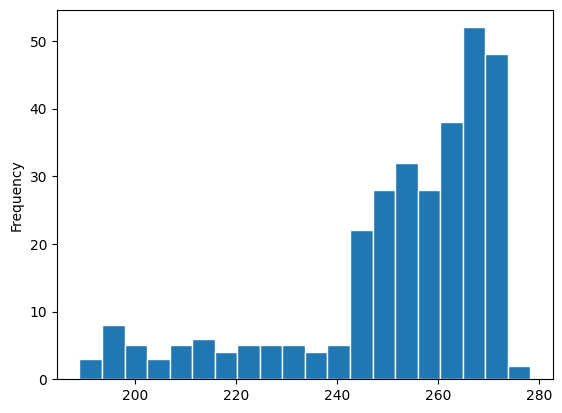

In [35]:
#proof of skewedness of data
test_dataset['CFC-11'].plot(kind='hist',bins=20,edgecolor='white')
plt.show()

Additionally, we now formally add the variable `continuous_months`, which allows us to refer to the data with minimal referencing to pandas' in-built date-time functions. 

In [36]:
dataset_fixed_months['continuous_months'] = dataset_fixed_months['Month'] + 12 * dataset_fixed_months['Year']

Reviewing all possible trends to see if theres any definite patterns for imputing aerosol data

### (to be deleted) this is just larry's attempt to plot the data for aerosol which is unneeded becuase we already have the table in cell 18

Focussing on the plot of `Year` against `Month`:

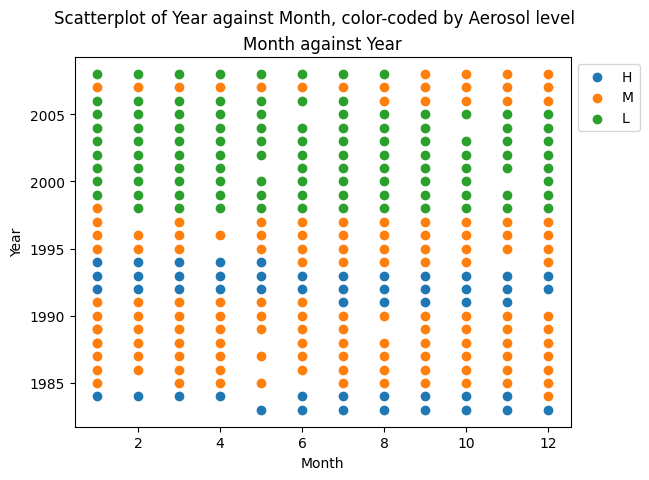

In [37]:
col1 = 'Month'
col2 = 'Year'

#  obtain an array that contains no missing values for aerosol
cats_2a = dataset['Aerosols'].dropna().unique()

dataset_for_plotting = dataset_fixed_months.copy()

for cat in cats_2a:
    filtered_dataset = dataset_for_plotting[dataset_for_plotting['Aerosols'] == cat]
    plt.scatter(filtered_dataset[col1], filtered_dataset[col2], label=cat)
    
plt.xlabel(col1)
plt.ylabel(col2)
plt.title(f"{col1} against {col2}")
plt.legend(cats_2a,bbox_to_anchor=(1, 1))
    
plt.suptitle("Scatterplot of Year against Month, color-coded by Aerosol level")

plt.show()

Gaps in the graph of year against month indicate missing aerosol values. It can be observed that since the aerosol levels for adjacent months of all the missing values are usually the same, we can impute the samples with missing data following the assumption that if the samples from adjacent months have the same aerosol value, the sample itself will also have the same aerosol value. (ie  Aerosol = 'M' for samples (1,1997) and (3,1997), hence we impute (2,1997) to also have Aerosol = 'M' where applicable).

Fixing aerosol category:

In [38]:
# get rows with missing Aerosol values
Aerosol_missing_values = dataset_fixed_months[dataset_fixed_months['Aerosols'].isna()]

analysed_rows = ['Year','Month','Aerosols']


for current_index,row in Aerosol_missing_values.iterrows():
    #get previous index's year and month
    prior_index = current_index - 1
    prev_A_level = dataset_fixed_months.loc[prior_index, 'Aerosols']
    
    next_index = current_index + 1
    next_A_level = dataset_fixed_months.loc[next_index, 'Aerosols']
    
    #fill rows with the same adjacent Aerosol values
    if prev_A_level == next_A_level:
        dataset_fixed_months.loc[current_index,'Aerosols'] = prev_A_level

# finalize dataset by dropping unfillable Aerosol values
dataset_full_clean = dataset_fixed_months.copy()


Visualising data after imputing missing Aerosol values:

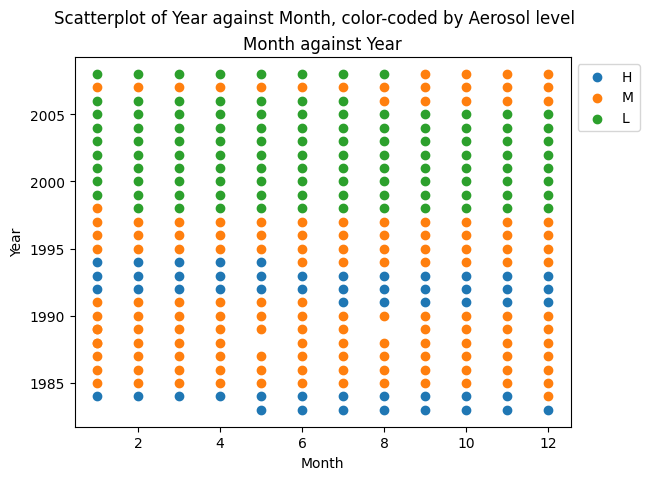

In [39]:
col1 = 'Month'
col2 = 'Year'

for cat in cats_2a:
    filtered_dataset = dataset_full_clean[dataset_full_clean['Aerosols'] == cat]
    plt.scatter(filtered_dataset[col1], filtered_dataset[col2], label=cat)
    
plt.xlabel(col1)
plt.ylabel(col2)
plt.title(f"{col1} against {col2}")
plt.legend(cats_2a,bbox_to_anchor=(1, 1))
    
plt.suptitle("Scatterplot of Year against Month, color-coded by Aerosol level")

plt.show()

---

**b.** For each variable, identify outliers (if any) and describe how you resolve the issue. Clearly state any assumption you made.

**Response.** 

Review all columns with numerical data

In [40]:
num_float64_columns = dataset.select_dtypes(include=['float64'])
print(f"Number of columns with dtype float64 (total: {num_float64_columns.shape[1]}):")
print('\t\n'.join(num_float64_columns))

Number of columns with dtype float64 (total: 7):
Month	
MEI	
CO2	
CH4	
CFC-11	
CFC-12	
Temp


Following prescribed outlier extraction method: observe outlier values, defined as values that are outside the boxplot(more than 1.5 * IQR + Q3 or Q1 - 1.5 * IQR).


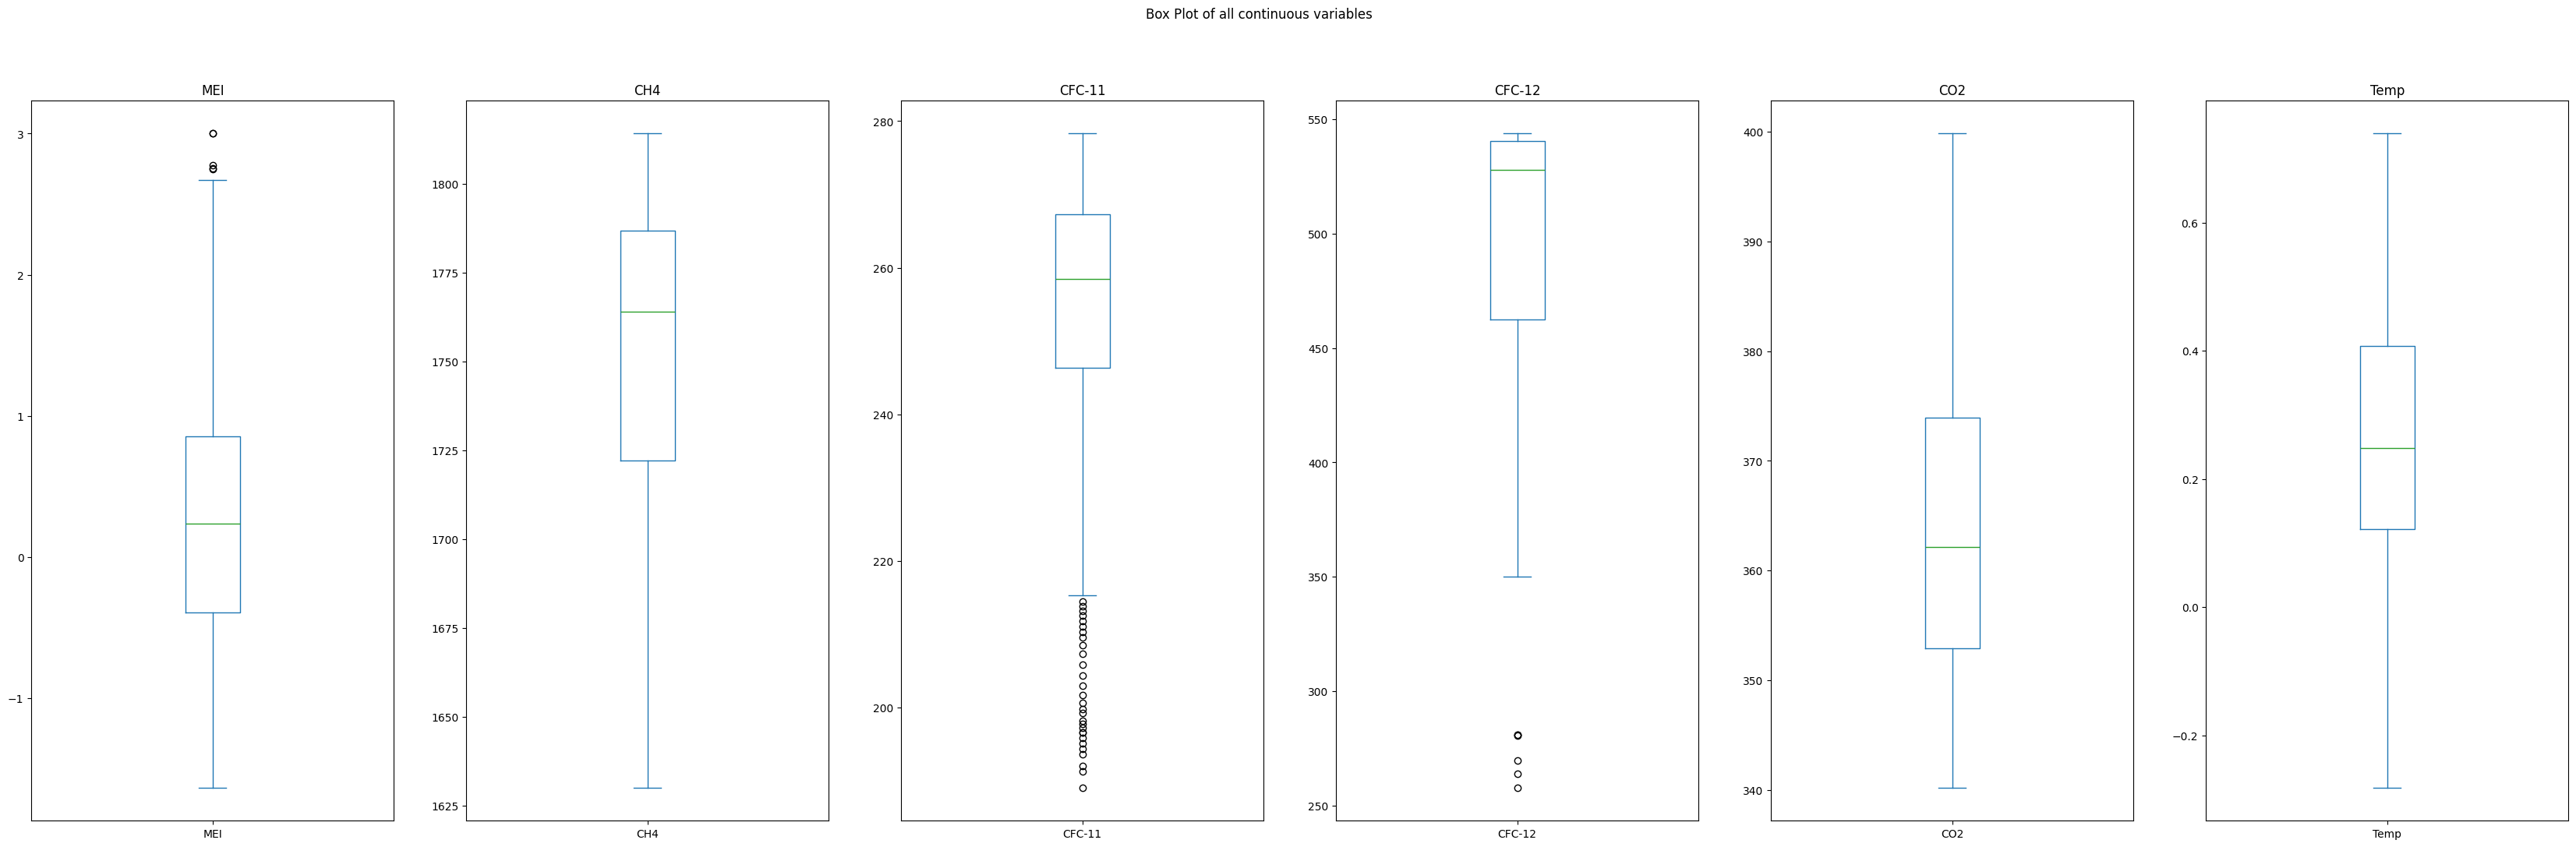

In [41]:
#dataset.dtypes
num_float64_columns = dataset.select_dtypes(include=['float64']).shape[1]
cols = list(dataset.select_dtypes(include=['float64']))
#CHANGE HERE
excluded_cols = {'Month','continuous_months'}

plottable_columns = list(set(cols) - excluded_cols)

#fig, axes = plt.subplots(num_float64_columns,1, sharex=True, sharey=True, layout="constrained")
fig, axes = plt.subplots(1,len(plottable_columns),figsize = (len(plottable_columns) * 7,12))
#plt.figure(figsize=(200, 250))
for i in range(len(plottable_columns)):
    
    column_name = plottable_columns[i]
    if column_name not in excluded_cols:
        dataset_full_clean[column_name].plot(ax=axes[i],kind='box')
        
        axes[i].set_title(column_name)
plt.suptitle("Box Plot of all continuous variables")

plt.show()

Created  `get_outliers` with function that assigns outlier sample references to dataframe under another variable

In [42]:
def get_outliers(Dataframe, column_name):
    Q1 = Dataframe[column_name].quantile(0.25)
    Q3 = Dataframe[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return Dataframe[(Dataframe[column_name] < lower_bound) | (Dataframe[column_name] > upper_bound)]

CFC_11_outliers = get_outliers(dataset_full_clean, 'CFC-11')
print("Number of outliers for column 'CFC-11':",CFC_11_outliers.shape[0])
print("proportion of data that is an outlier:",round(CFC_11_outliers.shape[0]/dataset_full_clean.shape[0]*100,2),'%')

CFC_12_outliers = get_outliers(dataset_full_clean, 'CFC-12')
print("Number of outliers for column 'CFC-12':",CFC_12_outliers.shape[0])
print("proportion of data that is an outlier:",round(CFC_12_outliers.shape[0]/dataset_full_clean.shape[0]*100,2),'%')

MEI_outliers = get_outliers(dataset_full_clean, 'MEI')
print("Number of outliers for column 'MEI':",MEI_outliers.shape[0])
print("proportion of data that is an outlier:",round(MEI_outliers.shape[0]/dataset_full_clean.shape[0]*100,2),'%')


Number of outliers for column 'CFC-11': 29
proportion of data that is an outlier: 9.42 %
Number of outliers for column 'CFC-12': 6
proportion of data that is an outlier: 1.95 %
Number of outliers for column 'MEI': 5
proportion of data that is an outlier: 1.62 %


Based on visual observation of the box plots of the samples in the dataset over each of the columns with numerical datatypes, there are outliers present in the columns `CFC-11`, `CH4` and `CFC-12`, where these samples have values that exceed 1.5 times the interquartile range. The columns with apparent outliers are elaborated on with the table below:

|Column with Outliers|Justifications|
|---|---|
| `CFC-11` | There are 29 samples that are considered outliers. This equates to 9.42% of datapoints of CFC-11. |
| `CFC-12` |  There are 6 samples that are considered as outliers. This equates to 1.95% of datapoints of CFC-12. |
| `MEI` | There are 5 samples that are considered outliers. This equates to 1.62% of datapoints of MEI.  |  

Visual analysis of `CFC-11` data to check for outliers

CFC-11 Summary statistics
count    308.000000
mean     492.804607
std       65.554230
min      257.574000
25%      462.543000
50%      527.776500
75%      540.348000
max      543.813000
Name: CFC-12, dtype: float64


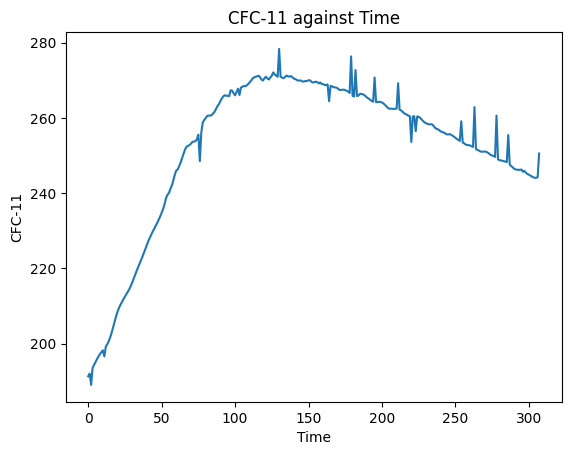

In [43]:
dataset_full_clean['CFC-11'].plot(kind='line',title='CFC-11 against Time',xlabel = 'Time',ylabel="CFC-11")

print('CFC-11 Summary statistics')
print(dataset_full_clean['CFC-12'].describe())

Since all the datapoints form a visible trend without obvious difference from the trend, we conclude that CFC-11 does not contain outlier data.

Visual analysis that `CFC-12` data to check for outliers

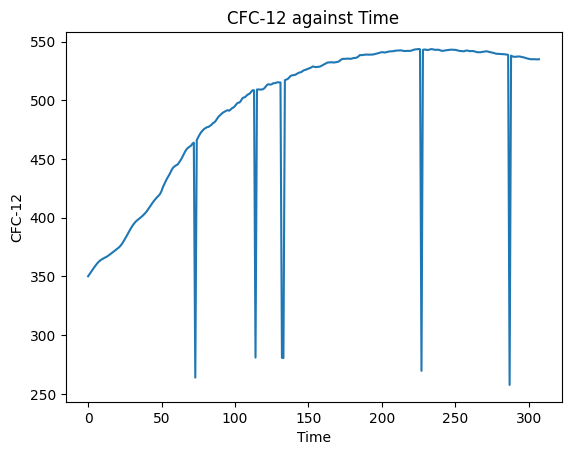

In [44]:
dataset_full_clean['CFC-12'].plot(kind='line',title='CFC-12 against Time',xlabel='Time',ylabel='CFC-12')

plt.show()

Obtaining Dataframe of outliers

In [45]:
CFC_12_outliers = dataset_full_clean[dataset_full_clean['CFC-12']<300]
print(CFC_12_outliers)

     Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
73   1989    6.0 -0.273  355.30  1713.80   L  253.793  263.793   M        M   
114  1992   11.0  0.602  354.27  1755.29   L  270.886  280.886   M        H   
132  1994    5.0  0.521  361.68  1755.04   L  270.691  280.691   M        H   
133  1994    6.0  0.734  360.80  1746.61   L  270.516  280.516   M        M   
227  2002    4.0  0.339  375.00  1782.47   L  259.574  269.574   H        L   
287  2007    4.0 -0.049  386.40  1802.11   L  247.574  257.574   L        M   

      Temp  continuous_months  
73   0.094            23874.0  
114 -0.097            23915.0  
132  0.218            23933.0  
133  0.191            23934.0  
227  0.443            24028.0  
287  0.466            24088.0  


Hence, these 6 outliers should be removed since they deviate greatly from their adjacent values.

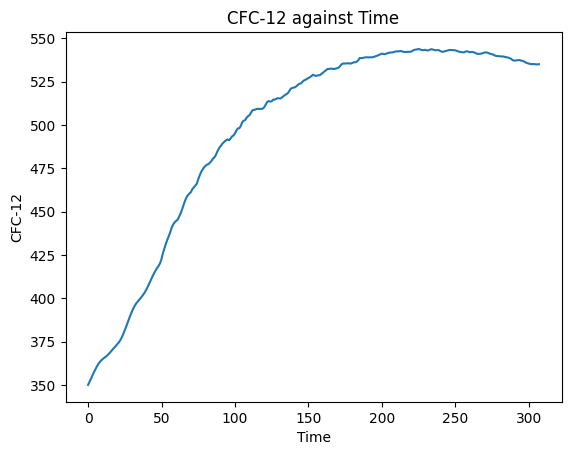

In [46]:
CFC_12_outliers_removed = dataset_full_clean[dataset_full_clean['CFC-12']>=300]
CFC_12_outliers_removed['CFC-12'].plot(kind='line',title='CFC-12 against Time',xlabel='Time',ylabel='CFC-12')

plt.show()

dataset_full_clean = CFC_12_outliers_removed.copy()

After removing the outliers, we can now conclude that there are no outliers in the datapoint of CFC-12 against time

Visualising `CH4` data based on samples over time

CH4 Outliers:
     Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
170  1997    7.0  2.756  364.34  1751.61   L  267.784  532.827   L        M   
171  1997    8.0  3.001  362.20  1750.23   L  267.441  533.315   M        M   
172  1997    9.0  3.000  360.31  1775.56   L  267.414  534.415   L        M   
177  1998    2.0  2.777  365.98  1766.01   L  266.978  535.561   M        L   
178  1998    3.0  2.748  367.13  1774.54   L  266.593  535.421   M        L   

      Temp  continuous_months  
170  0.372            23971.0  
171  0.406            23972.0  
172  0.457            23973.0  
177  0.739            23978.0  
178  0.520            23979.0  


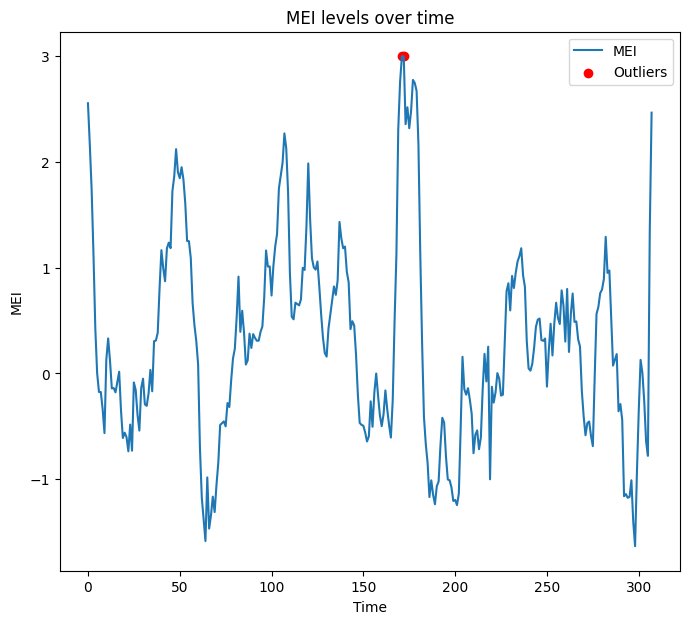

In [47]:
print("CH4 Outliers:")
print(MEI_outliers)

dataset_full_clean['MEI'].plot(kind='line',title='MEI levels over time',xlabel='Time',ylabel='MEI',figsize=(8,7))
MEI_outliers = get_outliers(dataset_full_clean, 'MEI')
plt.scatter(MEI_outliers.index, MEI_outliers['MEI'], color='red')
plt.legend(['MEI','Outliers'],loc='best')

plt.show()

No observable trend was present to indicate that outliers should be removed on the basis of deviation from time sampled, hence outlier samples flagged under `MEI` variable should be retained.

**c.** For categorical variables, perform the necessary encoding.

We will interpret the all 3 categorical variables to be ordinal as the values that they can take on, 'L', 'M' and 'H' can be ranked as such in ascending order of chemical or energy intensity, thus we will perform ordinal encoding for their associated columns.

In [48]:
# performing categorical encoding over non-numeric columns
# storing final dataset under variable "dataset_clean_encoded"

dataset_clean_encoded = dataset_full_clean.copy()

all_cols = dataset_full_clean.columns
num_cols = list(dataset.select_dtypes(include=['float64']))
excluded_cols = {'Month','Year','continuous_months'}

categorical_cols = list(set(all_cols)-set(num_cols)-excluded_cols)
categorical_cols.sort()
print('variables with categorical data:')
print(', '.join(categorical_cols))

encoding = {"L":0, "M":1,"H":2}
for cat in categorical_cols:
    dataset_clean_encoded[f'{cat}_ord'] = dataset_clean_encoded[cat].map(encoding)

#show processed data
print(dataset_clean_encoded.head())

variables with categorical data:
Aerosols, N2O, TSI
   Year  Month    MEI     CO2      CH4 N2O   CFC-11   CFC-12 TSI Aerosols  \
0  1983    5.0  2.556  345.96  1638.59   L  191.324  350.113   M        H   
1  1983    6.0  2.167  345.52  1633.71   L  192.057  351.848   M        H   
2  1983    7.0  1.741  344.15  1633.22   L  189.051  353.725   M        H   
3  1983    8.0  1.130  342.25  1631.35   L  193.602  355.633   M        H   
4  1983    9.0  0.428  340.17  1648.40   L  194.392  357.465   M        H   

    Temp  continuous_months  Aerosols_ord  N2O_ord  TSI_ord  
0  0.109            23801.0             2        0        1  
1  0.118            23802.0             2        0        1  
2  0.137            23803.0             2        0        1  
3  0.176            23804.0             2        0        1  
4  0.149            23805.0             2        0        1  


### 3.	Exploratory analysis and visualization [50% of Part I]

### **a.** For each variable, provide relevant summary statistics

**Response**: We now have a clean dataset for further analysis. We will first start with numerical datas. The numerical features we have are MEI, CO2, CH4, CFC-11, CFC-12, Temp. Below is the five-number summary statistics.

### Numerical dataset analysis (MEI, CO2, CH4, CFC-11, CFC-12, Temp)

In [49]:
dataset_clean_encoded[["MEI", "CO2", "CH4", "CFC-11", "CFC-12", "Temp"]].describe()

,MEI,CO2,CH4,CFC-11,CFC-12,Temp
count,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,0.285689,363.436887,1749.637848,251.928728,497.188030,0.257579
std,0.953268,13.070261,46.323190,20.499250,58.238429,0.178700
min,-1.635000,340.170000,1629.890000,189.051000,350.113000,-0.282000
25%,-0.404250,352.645000,1722.027500,246.272500,471.408250,0.122750
50%,0.225000,362.190000,1764.490000,258.344000,528.519000,0.249000
75%,0.869500,373.902500,1787.115000,267.137000,540.660750,0.406750
max,3.001000,399.850000,1814.180000,278.311000,543.813000,0.739000


#### To  visualize the distribution of this dataset and identify outliers of these numerical datasets, we will create boxplots.

### Categorical Dataset Analysist (TSI, Aerosol, N2O)

#### To analyse the categorical dataset, we record the number of counts of each level of every chemical and find its percentage value to understand the split in the chemical levels

In [50]:
def count_and_percentages(datasetColumn, heading=None):
    counts = datasetColumn.value_counts()
    percentages = counts / len(dataset_clean_encoded) * 100
    
    # Reset the index to make the levels a column instead of an index
    results_dataset = pd.DataFrame({
        'Chemical level': counts.index,
        'Counts': counts.values,
        'Percentages': percentages.values
    })
    
    # Reset the index and drop it to remove the 0,1,2 values
    results_dataset = results_dataset.reset_index(drop=True)
    
    if heading is not None:
        print(heading)
    print(results_dataset)
    print()


count_and_percentages(dataset_clean_encoded["N2O"], "Count and percentages of N2O levels:")
count_and_percentages(dataset_clean_encoded["TSI"], "Count and percentages of TSI levels:")
count_and_percentages(dataset_clean_encoded["Aerosols"], "Count and percentages of Aerosols levels:")

Count and percentages of N2O levels:
  Chemical level  Counts  Percentages
0              L     294    97.350993
1              H       8     2.649007

Count and percentages of TSI levels:
  Chemical level  Counts  Percentages
0              M     160    52.980132
1              L      90    29.801325
2              H      52    17.218543

Count and percentages of Aerosols levels:
  Chemical level  Counts  Percentages
0              M     141    46.688742
1              L     109    36.092715
2              H      52    17.218543



### **b.** For each variable, provide an appropriate visualisation depicting the distribution of its values, and summarize any key observation(s) you made.

#### **Response: Visualise using Boxplots for numerical variables and Histograms for categorical variables** 

#### **Numerical Dataset Visualisation (MEI, CO2, CH4, CFC-11, CFC-12, Temp)**

In [51]:
# First, define your dataset_numerics
dataset_numerics = dataset_clean_encoded[["MEI", "CO2", "CH4", "CFC-11", "CFC-12", "Temp"]]


## MEI

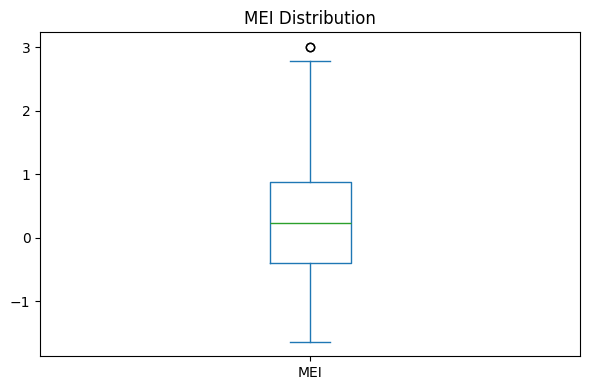

,MEI
count,302.000000
mean,0.285689
std,0.953268
min,-1.635000
25%,-0.404250
50%,0.225000
75%,0.869500
max,3.001000


In [52]:
# Plot MEI boxplot
plt.figure(figsize=(6, 4))
dataset_numerics["MEI"].plot(kind='box')
plt.title("MEI Distribution")
plt.tight_layout()
plt.show()

# Descriptive statistics for MEI
pd.DataFrame(dataset_clean_encoded["MEI"]).describe()


### **Observation**

### 1) Central Tendency:

The mean MEI value is approximately 0.29, indicating that on average, the MEI values in this dataset have a slightly positive tendency. This suggests that over the measured period, there was a slight bias toward El Niño conditions rather than La Niña.

The median is 0.225, which is slightly lower than the mean, suggesting a slight positive skew in the distribution. This indicates that while most values cluster around neutral to slightly positive conditions, there are some higher positive values (stronger El Niño events) pulling the mean upward.

### 2) Variability:

The standard deviation is 0.95, which indicates moderate variability in the dataset. This value suggests that MEI readings typically fluctuate within about one unit of the mean, representing the typical strength of ENSO events in either direction.

### 3) Range:

The dataset ranges from a minimum of -1.635 (indicating moderate La Niña conditions) to a maximum of 3.001 (indicating strong El Niño conditions). This range of approximately 4.64 units shows that the dataset captures both significant El Niño and La Niña events, with El Niño events reaching more extreme values.

### 4) Quartiles:

The 1st Quartile is -0.404, meaning 25% of the MEI values are below this threshold, representing La Niña or cool neutral conditions.

The 3rd Quartile is 0.870, indicating that 75% of the MEI values fall below this level, with the remaining 25% representing stronger El Niño conditions.

The IQR, calculated as the difference between the 3rd and 1st quartiles (0.870 - (-0.404) = 1.274), provides a measure of the middle 50% of the data's spread. This moderate IQR indicates typical variability in ENSO conditions, with the boxplot showing one outlier at the upper end representing an exceptionally strong El Niño event.

#### CO2

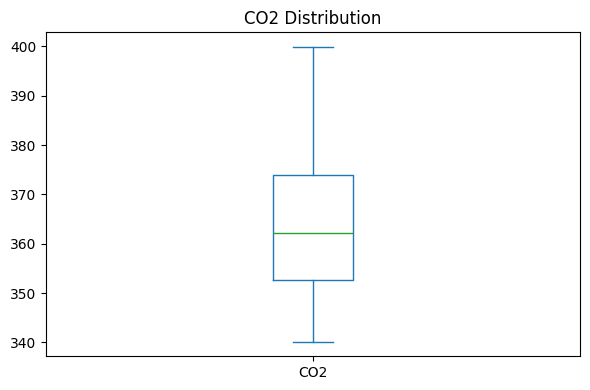

,CO2
count,302.000000
mean,363.436887
std,13.070261
min,340.170000
25%,352.645000
50%,362.190000
75%,373.902500
max,399.850000


In [53]:
# Plot CO2 boxplot
plt.figure(figsize=(6, 4))
dataset_numerics["CO2"].plot(kind='box')
plt.title("CO2 Distribution")
plt.tight_layout()
plt.show()

# Descriptive statistics for CO2
pd.DataFrame(dataset_clean_encoded["CO2"]).describe()

### **Observation**
#### 1) Central Tendency:
The mean CO2 concentration is approximately 363.44 ppm, indicating that on average, the atmospheric CO2 levels in this dataset are around this value. This represents the central point around which the dataset's values are distributed.

The median is 362.19 ppm, which is slightly lower than the mean, suggesting a slight positive skew in the distribution. This indicates that while most values cluster around the median, there are some higher CO2 readings pulling the mean upward.

#### 2) Variability:
The standard deviation is 13.07 ppm, which indicates the average distance of the data points from the mean. This moderate standard deviation suggests that CO2 levels typically vary within about 13 ppm of the mean, representing relatively consistent but still notable fluctuations in atmospheric CO2.

#### 3) Range:
The dataset ranges from a minimum of 340.17 ppm to a maximum of 399.85 ppm. This range of approximately 59.68 ppm shows considerable variation in CO2 levels over the measured period, likely capturing seasonal cycles and/or a long-term increasing trend in atmospheric CO2 concentrations.

#### 4) Quartiles:
The 1st Quartile is 352.65 ppm, meaning 25% of the CO2 values are below this threshold, representing the lower end of the distribution.

The 3rd Quartile is 373.90 ppm, indicating that 75% of the CO2 values fall below this level, with the remaining 25% representing higher CO2 concentrations.

The IQR, calculated as the difference between the 3rd and 1st quartiles (373.90 - 352.65 = 21.25 ppm), provides a measure of the middle 50% of the data's spread. This IQR indicates moderate variability in CO2 levels, with the boxplot showing no outliers, suggesting that all values fall within the expected range of variation.

#### CH4

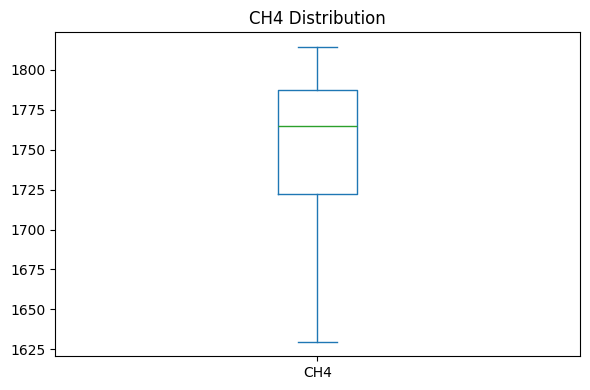

,CH4
count,302.000000
mean,1749.637848
std,46.323190
min,1629.890000
25%,1722.027500
50%,1764.490000
75%,1787.115000
max,1814.180000


In [54]:
# Plot CH4 boxplot
plt.figure(figsize=(6, 4))
dataset_numerics["CH4"].plot(kind='box')
plt.title("CH4 Distribution")
plt.tight_layout()
plt.show()

# Descriptive statistics for CH4
pd.DataFrame(dataset_clean_encoded["CH4"]).describe()


### **Observation**
### 1) Central Tendency:

The mean CH4 concentration is approximately 1749.64 ppb, indicating that on average, the atmospheric methane levels in this dataset are around this value. This represents the central point around which the dataset's values are distributed.

The median is 1764.49 ppb, which is slightly higher than the mean, suggesting a slight negative skew in the distribution. This indicates that while most values cluster around the median, there are some lower CH4 readings pulling the mean downward.

### 2) Variability:

The standard deviation is 46.32 ppb, which indicates the average distance of the data points from the mean. This standard deviation suggests that CH4 levels typically vary within about 46 ppb of the mean, representing moderate variability in atmospheric methane concentrations.

### 3) Range:

The dataset ranges from a minimum of 1629.89 ppb to a maximum of 1814.18 ppb. This range of approximately 184.29 ppb shows considerable variation in CH4 levels over the measured period, likely capturing seasonal cycles and/or a long-term trend in atmospheric methane concentrations.

### 4) Quartiles:

The 1st Quartile is 1722.03 ppb, meaning 25% of the CH4 values are below this threshold, representing the lower end of the distribution.

The 3rd Quartile is 1787.12 ppb, indicating that 75% of the CH4 values fall below this level, with the remaining 25% representing higher CH4 concentrations.

The IQR, calculated as the difference between the 3rd and 1st quartiles (1787.12 - 1722.03 = 65.09 ppb), provides a measure of the middle 50% of the data's spread. This IQR indicates moderate variability in CH4 levels, with the boxplot showing no outliers, suggesting that all values fall within the expected range of variation.

#### CFC-11

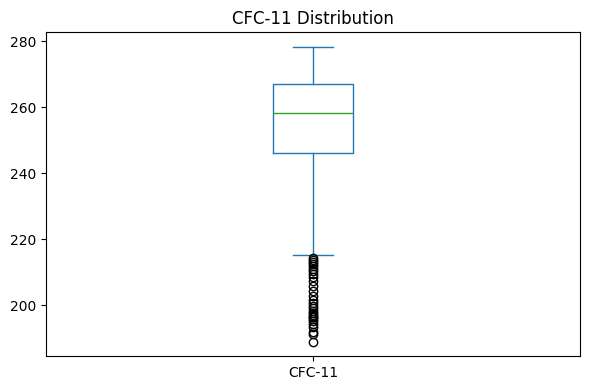

,CFC-11
count,302.000000
mean,251.928728
std,20.499250
min,189.051000
25%,246.272500
50%,258.344000
75%,267.137000
max,278.311000


In [55]:
# Plot CFC-11 boxplot
plt.figure(figsize=(6, 4))
dataset_numerics["CFC-11"].plot(kind='box')
plt.title("CFC-11 Distribution")
plt.tight_layout()
plt.show()

# Descriptive statistics for CFC-11
pd.DataFrame(dataset_clean_encoded["CFC-11"]).describe()

### **Observation**
### 1) Central Tendency:

The mean CFC-11 concentration is approximately 251.93 ppt, indicating that on average, the atmospheric CFC-11 levels in this dataset are around this value. This represents the central point around which the dataset's values are distributed.

The median is 258.34 ppt, which is higher than the mean, suggesting a negative skew in the distribution. This indicates that while most values cluster around the median, there are some lower CFC-11 readings pulling the mean downward.

### 2) Variability:

The standard deviation is 20.50 ppt, which indicates the average distance of the data points from the mean. This standard deviation suggests that CFC-11 levels typically vary within about 20.5 ppt of the mean, representing moderate variability in atmospheric CFC-11 concentrations.

### 3) Range:

The dataset ranges from a minimum of 189.05 ppt to a maximum of 278.31 ppt. This range of approximately 89.26 ppt shows considerable variation in CFC-11 levels over the measured period, likely capturing a decreasing trend in atmospheric CFC-11 concentrations due to the Montreal Protocol restrictions.

### 4) Quartiles:

The 1st Quartile is 246.27 ppt, meaning 25% of the CFC-11 values are below this threshold, representing the lower end of the distribution.

The 3rd Quartile is 267.14 ppt, indicating that 75% of the CFC-11 values fall below this level, with the remaining 25% representing higher CFC-11 concentrations.

The IQR, calculated as the difference between the 3rd and 1st quartiles (267.14 - 246.27 = 20.87 ppt), provides a measure of the middle 50% of the data's spread. This IQR indicates moderate variability in CFC-11 levels.

The boxplot shows multiple outliers at the lower end of the distribution, suggesting several measurements with unusually low CFC-11 concentrations, which likely represent more recent measurements as CFC-11 levels have declined over time due to international regulations.

#### CFC-12

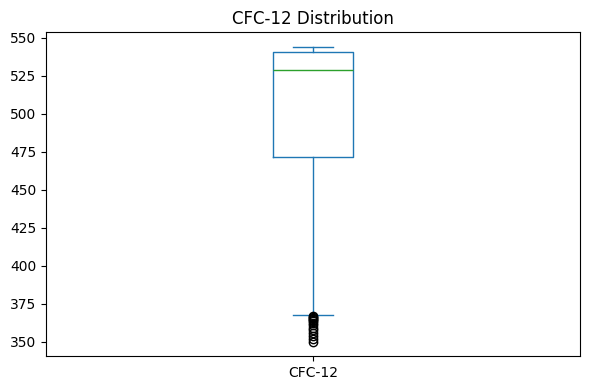

,CFC-12
count,302.000000
mean,497.188030
std,58.238429
min,350.113000
25%,471.408250
50%,528.519000
75%,540.660750
max,543.813000


In [56]:
# Plot CFC-12 boxplot
plt.figure(figsize=(6, 4))
dataset_numerics["CFC-12"].plot(kind='box')
plt.title("CFC-12 Distribution")
plt.tight_layout()
plt.show()

# Descriptive statistics for CFC-12"
pd.DataFrame(dataset_clean_encoded["CFC-12"]).describe()

### **Observation**
### 1) Central Tendency:

The mean CFC-12 concentration is approximately 497.19, indicating that on average, the samples in this dataset have a CFC-12 level of about 497.19 units. This value is a central point around which the dataset's values are distributed.

The median is 528.52 units, which is higher than the mean, suggesting a left-skewed distribution of data. This indicates that there are likely some lower values pulling the mean down, while the majority of the data points are clustered at higher values.

### 2) Variability:

The standard deviation is 58.24 units, which indicates the average distance of the data points from the mean. This standard deviation suggests moderate variability in the dataset, with most samples having CFC-12 levels that vary within this range around the mean.

### 3) Range:

The dataset ranges from a minimum of 350.11 units to a maximum of 543.81 units. This range of approximately 193.7 units indicates the overall spread of the CFC-12 levels in the samples, showing considerable variation across different measurements.

### 4) Quartiles:

The 1st Quartile is 471.41 units, meaning 25% of the samples have a CFC-12 level lower than this value. This could indicate a group of samples with notably lower CFC-12 concentration.

The 3rd Quartile is 540.66 units, so 75% of the samples have a CFC-12 level below this value. This suggests that a majority of the samples have CFC-12 levels that cluster toward the higher end of the distribution.

The IQR, calculated as the difference between the 3rd and 1st quartiles (540.66 - 471.41 = 69.25), provides a measure of the middle 50% of the data's spread. This IQR indicates that the central half of the dataset shows significant variation.

The box plot also reveals several outliers at the lower end of the distribution (shown as black circles), suggesting some samples have unusually low CFC-12 concentrations compared to the majority of the dataset.

#### Temp

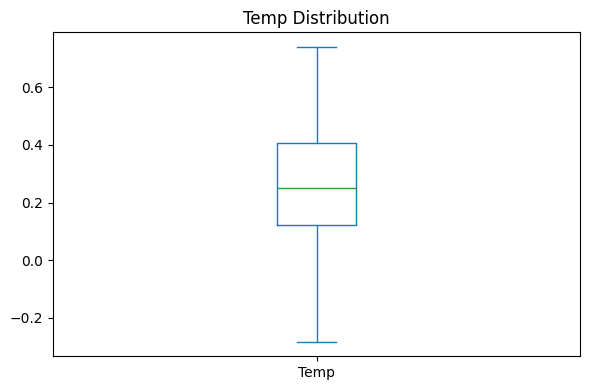

,Temp
count,302.000000
mean,0.257579
std,0.178700
min,-0.282000
25%,0.122750
50%,0.249000
75%,0.406750
max,0.739000


In [57]:
# Plot Temp boxplot
plt.figure(figsize=(6, 4))
dataset_numerics["Temp"].plot(kind='box')
plt.title("Temp Distribution")
plt.tight_layout()
plt.show()

# Descriptive statistics for Temp
pd.DataFrame(dataset_clean_encoded["Temp"]).describe()

### **Observation**
### 1) Central Tendency:

The mean temperature is approximately 0.26, indicating that on average, the samples in this dataset have a temperature level of about 0.26 units. This value is a central point around which the dataset's values are distributed.

The median is 0.249 units, which is very close to the mean, suggesting a relatively symmetric distribution of data around the central value. The median being so close to the mean indicates that there are likely no extreme outliers significantly skewing the distribution.

### 2) Variability:

The standard deviation is 0.179 units, which indicates the average distance of the data points from the mean. This standard deviation suggests relatively low variability in the dataset, with most samples having temperature levels that vary within a narrow range around the mean.

### 3) Range:

The dataset ranges from a minimum of -0.282 units to a maximum of 0.739 units. This range of approximately 1.021 units indicates the overall spread of the temperature levels in the samples, showing moderate variation across different measurements.

### 4) Quartiles:

The 1st Quartile is 0.123 units, meaning 25% of the samples have a temperature level lower than this value.

The 3rd Quartile is 0.407 units, so 75% of the samples have a temperature level below this value.

The IQR, calculated as the difference between the 3rd and 1st quartiles (0.407 - 0.123 = 0.284), provides a measure of the middle 50% of the data's spread. This relatively small IQR indicates that the central half of the dataset is fairly compact.

The box plot shows a fairly symmetric distribution without visible outliers, suggesting that the temperature values are distributed evenly around the median with no unusual extreme values.

### **Categorical Dataset Visualisation (TSI, Aerosol, N2O)**

### **N2O**

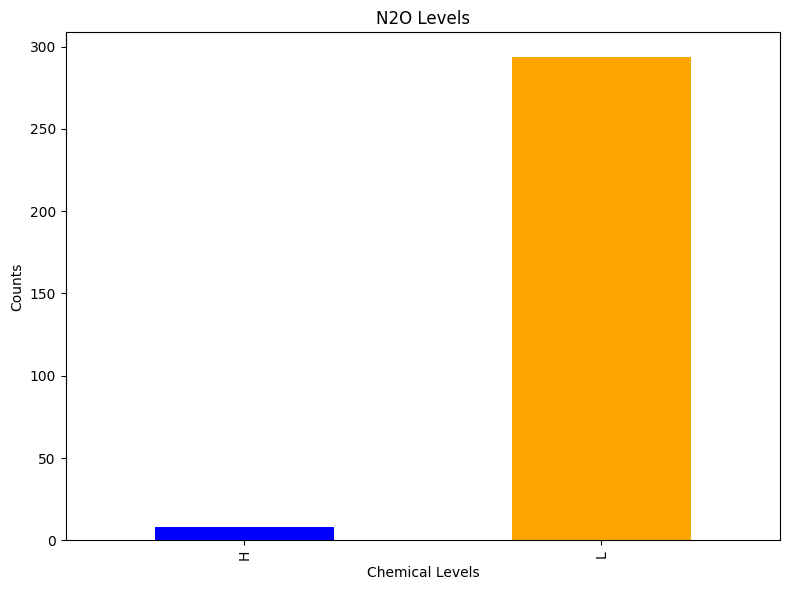

  Chemical level  Counts  Percentages
0              L     294    97.350993
1              H       8     2.649007



In [58]:
chemical = "N2O"
counts = dataset_clean_encoded[chemical].value_counts().sort_index()

plt.figure(figsize=(8, 6))
counts.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title(f"{chemical} Levels")
plt.xlabel("Chemical Levels")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

count_and_percentages(dataset_clean_encoded["N2O"])


# **Observations**:

The histogram shows the distribution of N2O categorized by its levels: Low (L), Medium (M), and High (H).

### Low N2O Levels:
The vast majority of N2O measurements fall into the 'Low' category (294 out of 302, or 97.35%). This extremely skewed distribution indicates that N2O levels are predominantly low in the dataset. The high proportion of low N2O levels might suggest that this is the normal or baseline state for this chemical in the environment being studied, with higher levels potentially indicating unusual conditions or anomalies.

### High N2O Levels:
Only a small fraction of samples (8 samples, or 2.65%) show high levels of N2O. This suggests that high N2O concentrations are rare occurrences in the measured environment. These outliers might represent specific events or conditions that temporarily increased N2O levels, or they could be measurement anomalies.

Overall, the histogram reveals a distinct pattern for N2O with predominantly low levels and occasional high readings. This pattern might reflect the natural behavior of N2O in the environment or could be related to the specific thresholds used to define the low and high categories.

#### **TSI**

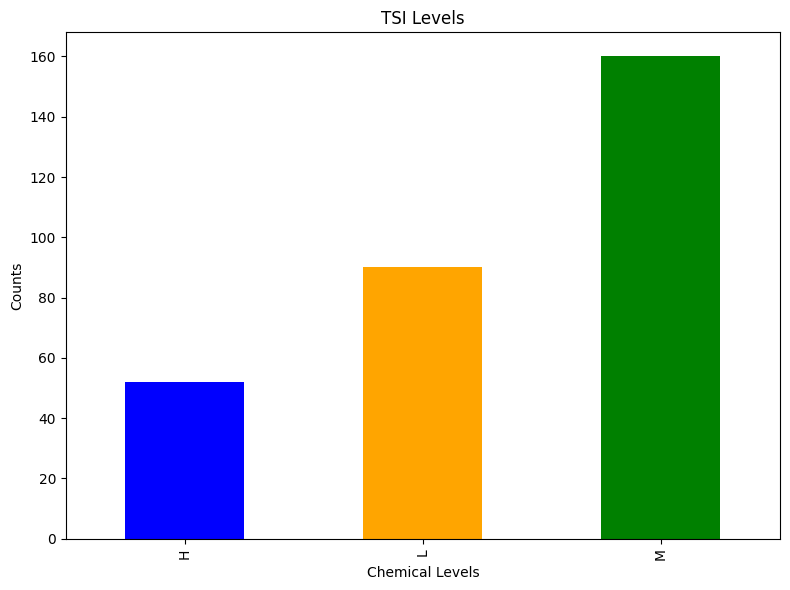

  Chemical level  Counts  Percentages
0              M     160    52.980132
1              L      90    29.801325
2              H      52    17.218543



In [59]:
chemical = "TSI"
counts = dataset_clean_encoded[chemical].value_counts().sort_index()

plt.figure(figsize=(8, 6))
counts.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title(f"{chemical} Levels")
plt.xlabel("Chemical Levels")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

count_and_percentages(dataset_clean_encoded["TSI"])

# **Observations**:

The histogram shows the distribution of TSI (Total Solar Irradiance) categorized by its levels: Low (L), Medium (M), and High (H).

### Medium TSI Levels:
The largest proportion of TSI measurements falls into the 'Medium' category (160 out of 302, or 52.98%). This indicates that medium TSI levels are the most common in the dataset. The predominance of medium values suggests that TSI typically operates within a moderate range, which might represent normal or expected conditions for solar irradiance in the environment being studied.

### Low TSI Levels:
The second most common category is 'Low' TSI levels (90 out of 302, or 29.80%). There is a significant number of measurements showing lower than medium solar irradiance, which could correspond to periods of reduced solar activity, seasonal variations, or other factors that diminish solar radiation reaching the measurement point.

### High TSI Levels:
The 'High' TSI category contains the smallest proportion of measurements (52 out of 302, or 17.22%). This indicates that there are fewer instances of high solar irradiance in this dataset. These high readings might represent peak solar activity periods, seasonal maxima, or specific conditions that enhance solar radiation.

Overall, the histogram reveals a distribution that peaks at medium levels and tapers off toward both low and high extremes, with a greater tendency toward low rather than high values. This pattern might reflect the natural variability of solar irradiance or could be related to the specific thresholds used to define the low, medium, and high categories.

#### **Aerosol**

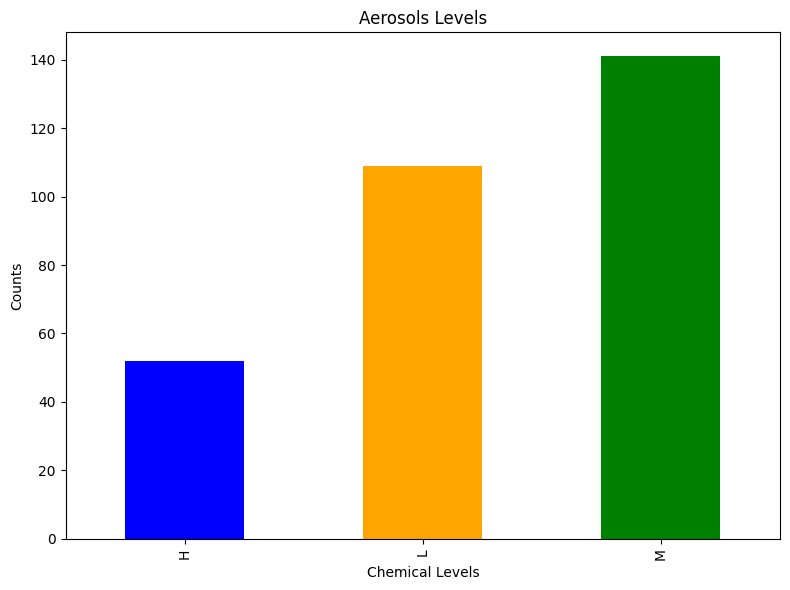

  Chemical level  Counts  Percentages
0              M     141    46.688742
1              L     109    36.092715
2              H      52    17.218543



In [60]:
chemical = "Aerosols"
counts = dataset_clean_encoded[chemical].value_counts().sort_index()

plt.figure(figsize=(8, 6))
counts.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title(f"{chemical} Levels")
plt.xlabel("Chemical Levels")
plt.ylabel("Counts")
plt.tight_layout()
plt.show()

count_and_percentages(dataset_clean_encoded["Aerosols"])

# **Observations**:

The histogram shows the distribution of Aerosols categorized by their levels: Low (L), Medium (M), and High (H).

### Medium Aerosol Levels:
The largest proportion of Aerosol measurements falls into the 'Medium' category (141 out of 302, or 46.69%). This indicates that medium aerosol levels are the most common in the dataset. The predominance of medium values suggests that aerosol concentrations typically operate within a moderate range in the environment being studied, possibly representing normal background conditions.

### Low Aerosol Levels:
The second most common category is 'Low' aerosol levels (109 out of 302, or 36.09%). There is a significant number of measurements showing lower aerosol concentrations, which could correspond to periods of cleaner air, perhaps after precipitation events that wash aerosols from the atmosphere, or during conditions that limit aerosol production or transport.

### High Aerosol Levels:
The 'High' aerosol category contains the smallest proportion of measurements (52 out of 302, or 17.22%). This indicates that there are fewer instances of high aerosol concentrations in this dataset. These high readings might represent pollution events, dust storms, volcanic activity, or other specific conditions that temporarily increase aerosol loading in the atmosphere.

Overall, the histogram reveals a distribution that is weighted toward medium levels, with substantial representation in the low category and fewer instances in the high category. This pattern might reflect the natural variability of aerosols in the environment or could be related to the specific thresholds used to define the low, medium, and high categories.|

### **c.** Perform bi-variate analysis on the variables. You do not need to present the analysis of every pair of variables; only focus on the pairs you believe are worth investigating and explain. For each pair, describe the relationship between the two variables. Use appropriate statistical methods and/or visualizations.

**Response.** 

Bi-variate analysis focussing on categorical variables

In [61]:
pd.crosstab(dataset_clean_encoded.TSI, dataset_clean_encoded.Aerosols)

Aerosols,H,L,M
TSI,,,
H,6,27,19
L,6,9,75
M,40,73,47


Plotting heatmap for assessing correlation values for continuous data:

In [64]:
month_save = dataset.copy()
dataset_fixed_months = month_save.copy()
dataset_fixed_months['continuous_months'] = dataset_fixed_months['Month'] + 12 * dataset_fixed_months['Year']
dataset_for_plotting = dataset_fixed_months.copy()
cols = list(dataset_for_plotting.select_dtypes(include=['float64','int64']))
categorical_cols = ['Aerosols_ord','N2O_ord','TSI_ord']

continuous_variables = list(set(cols) - set(categorical_cols))

print('Columns with continuous data:')
print(', '.join(continuous_variables))

Columns with continuous data:
MEI, continuous_months, Month, CH4, CFC-11, Year, CFC-12, CO2, Temp


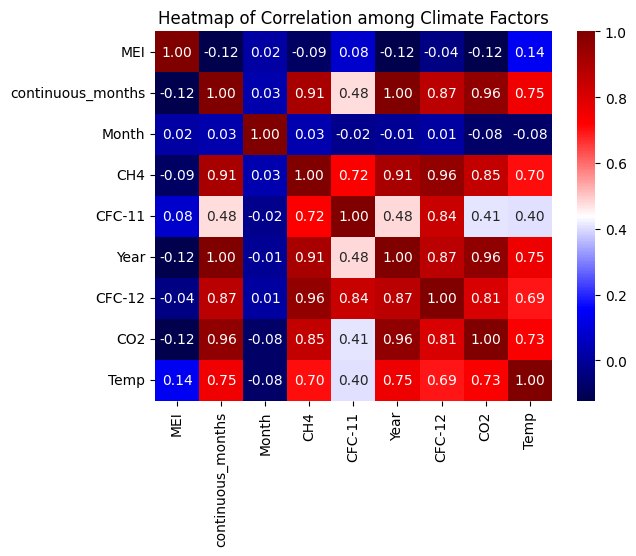

In [65]:
import seaborn as sns
datatset_correlations = dataset_clean_encoded[continuous_variables].corr()

sns.heatmap(datatset_correlations, annot=True, fmt='.2f', cmap='seismic')
plt.title('Heatmap of Correlation among Climate Factors')
plt.show()

# Observations:

Based on the above heatmap, we noticed that majority of the correlation values have absolute values of less than 0.8. Hence, we determined that it is sufficient enough to set the threshold level for meaningful relationships to be 0.8. We chose a rather conservative value of 0.8 as it indicates a moderate level of correlation between variables. As this value is close to 1, it suggests a strong association between the variables. 

Based on our considerations, we decided to proceed with the bi-vaiate analysis of 1) CO2 and CFC-12, 2) CO2 & CH4, 3) CO2 & continuous_months, 4) CFC-12 & continuous_months, 5)  CH4 & continuous_months, 6) CFC-12 & CFC-11, 7)  CFC-12 and CH4

The correlation values for all pairs ( 1, 2, 3, 4, 5, 6 and 7 ) are positive, so there is likely to be positive relationships.

### Moving forward, a Scatter plot would be used to analyse the relationship between these 7 pairs


First, we would create a function that can be used to plot scatterplot diagrams between 2 variables, **`plot_with_coefficient`**:

In [66]:
def plot_with_coefficient(column1:str, column2:str, dataset_clean_encoded:pd.DataFrame, modifier = '',folder_mod = 'ungrouped/'):
    '''
    column1 is the x axis
    column2 is the y axis
    modifier to make a note of anything different
    '''
    
    cols = list(dataset_clean_encoded.select_dtypes(include=['float64']))
    #CHANGE HERE
    excluded_cols = {'Month'}
    plottable_columns = list(set(cols) - excluded_cols)

    datatset_correlations_local = dataset_clean_encoded[plottable_columns].corr()
    # 
    corr_num = round(datatset_correlations_local[column1][column2], 3)
    plt.figure()  # Create a new figure
    ax = plt.axes()
    ax.scatter(dataset_clean_encoded[column1], dataset_clean_encoded[column2])
    # Make sure we're using function calls
    ax.set_xlabel(column1)
    ax.set_ylabel(column2)
    
    ax.set_title(f"{column2} against {column1} (correlation coefficient {corr_num})")

    folder_name = GRAPH_FILEPATH+f'3c/{column1}/{folder_mod}'
    os.makedirs(folder_name, exist_ok=True) 
    plt.savefig(folder_name+f"3c_FINAL_{column1}_{column2}_scatterplot{modifier}.png")
    plt.show()

### Pair 1: CO2 and CFC-12

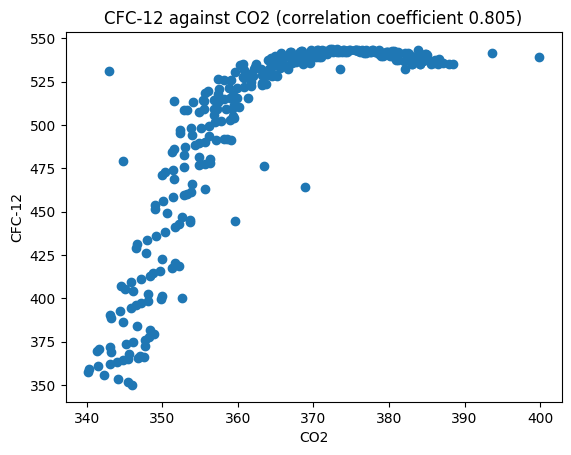

In [342]:
plot_with_coefficient('CO2','CFC-12',dataset_clean_encoded)

There is a clear positive correlation between CO2 and CFC-12 concentrations

As CO2 levels increase from around 340 to 400 ppm, CFC-12 levels rise from approximately 350 to 540 parts per trillion

The relationship appears to be somewhat non-linear, with the slope becoming less steep at higher CO2 concentrations

The data points form a generally upward trajectory, indicating that both greenhouse gases have been increasing together

### Pair 2: CO2 & CH4

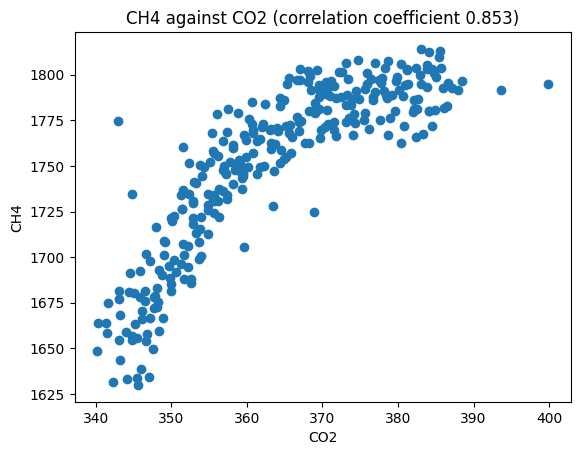

In [333]:
plot_with_coefficient('CO2','CH4',dataset_clean_encoded)

There is a clear positive correlation between CO2 and CH4 concentrations with a strong correlation coefficient of 0.853

As CO2 levels increase from around 340 to 400 ppm, CH4 levels rise from approximately 1625 to 1800 ppb

The relationship appears to be somewhat non-linear, with increased scatter at higher CO2 concentrations

The data points form a generally upward trajectory, indicating that both greenhouse gases have been increasing together

### Pair 3: CO2 & continuous_months

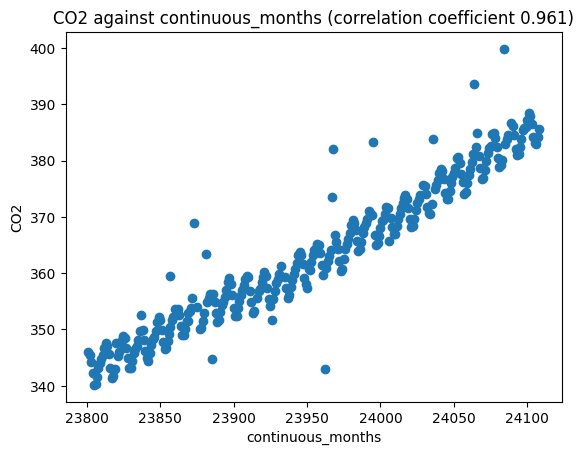

In [347]:
plot_with_coefficient('continuous_months','CO2',dataset_clean_encoded)

There is a clear positive correlation between CO2 and continuous months with a very strong correlation coefficient of 0.961

As time progresses (continuous months from approximately 23800 to 24100), CO2 levels increase steadily from around 340 to 400 ppm

The relationship appears to be predominantly linear, showing a consistent upward trend over time

The data points form a tight, upward trajectory with a clear pattern, indicating a steady increase in atmospheric CO2 concentration over the measured time period

The data shows some cyclical patterns visible as wave-like formations, likely representing seasonal variations in CO2 levels

### Pair 4: CFC-12 & continuous_months

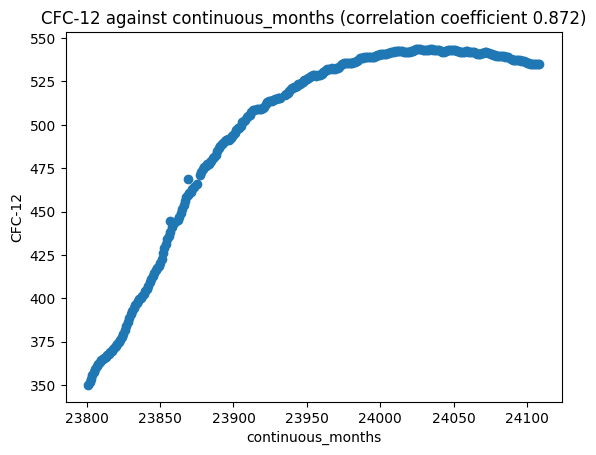

In [346]:
plot_with_coefficient('continuous_months','CFC-12',dataset_clean_encoded)

There is a strong positive correlation between CFC-12 and continuous months with a correlation coefficient of 0.872

As time progresses (continuous months from approximately 23800 to 24100), CFC-12 levels initially rise rapidly from around 350 to 540 parts per trillion

The relationship is distinctly non-linear, showing three phases: rapid initial increase, plateau, and slight decline

The data points form a very tight, well-defined curve with minimal scatter, indicating a consistent pattern of CFC-12 concentration changes over time

The graph shows a clear leveling off and slight decrease in CFC-12 levels after around month 24000, likely reflecting the impact of international regulations on CFC production and use

### Pair 5: CH4 & continuous_months

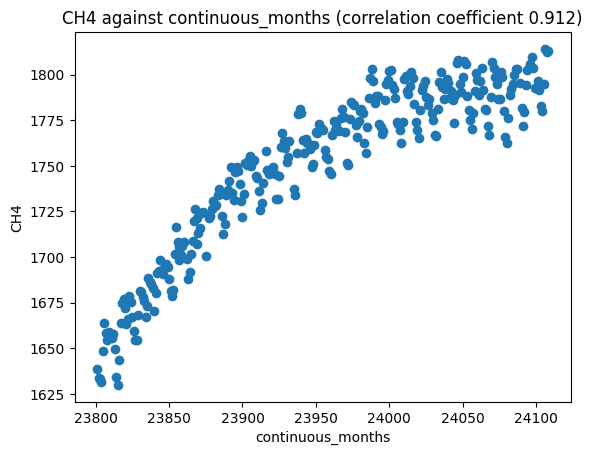

In [348]:
plot_with_coefficient('continuous_months','CH4',dataset_clean_encoded)

There is a strong positive correlation between CH4 and continuous months with a correlation coefficient of 0.912

As time progresses (continuous months from approximately 23800 to 24100), CH4 levels rise from around 1625 to 1800 parts per billion

The relationship appears non-linear, showing a steeper increase initially and then a more gradual rise with increased variability

The data points form a clear pattern with some scatter, particularly in the later months

The graph shows continued increase in CH4 levels throughout the time period, though the rate of increase appears to slow somewhat after around month 24000

The scatter of data points becomes more pronounced in the later period (after month 24000), suggesting greater variability in CH4 measurements

The overall trend indicates a persistent increase in atmospheric methane concentrations over the time period represented

The highest CH4 values (around 1820 ppb) appear near the end of the time series, suggesting methane levels were still rising at the end of the measurement period

### Pair 6: CFC-12 & CFC-11

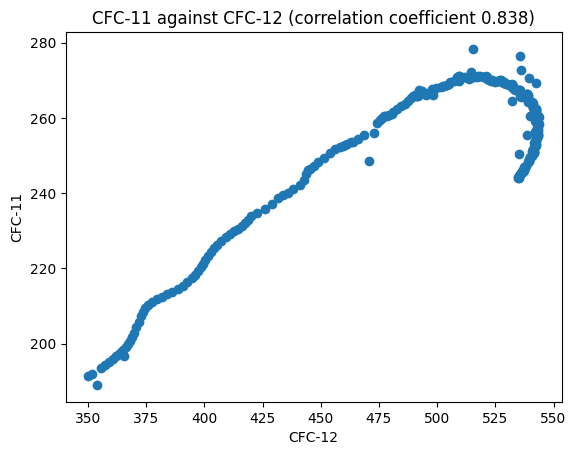

In [349]:
plot_with_coefficient('CFC-12','CFC-11',dataset_clean_encoded)

There is a strong positive correlation between CFC-11 and CFC-12 with a correlation coefficient of 0.838

As CFC-12 levels increase from approximately 350 to 525 parts per trillion, CFC-11 concentrations rise from about 190 to 270 parts per trillion

The relationship displays a complex, non-linear pattern with several distinct phases of growth and change

The data points form a very tight, well-defined curve with minimal scatter, indicating a consistent relationship between these two chlorofluorocarbons

The graph shows an interesting loop formation at higher concentration levels (CFC-12 > 525), where CFC-11 begins to decrease while CFC-12 continues to change

There appears to be a plateau in CFC-11 levels around 270 parts per trillion when CFC-12 reaches approximately 525 parts per trillion

After reaching maximum values, both compounds show evidence of decline, creating the distinctive hook or loop pattern at the upper end of the concentration range

The relationship suggests these two ozone-depleting substances have followed similar but not identical atmospheric concentration patterns, likely reflecting their related but distinct production, use, and regulation histories

### Pair 7: CFC-12 and CH4

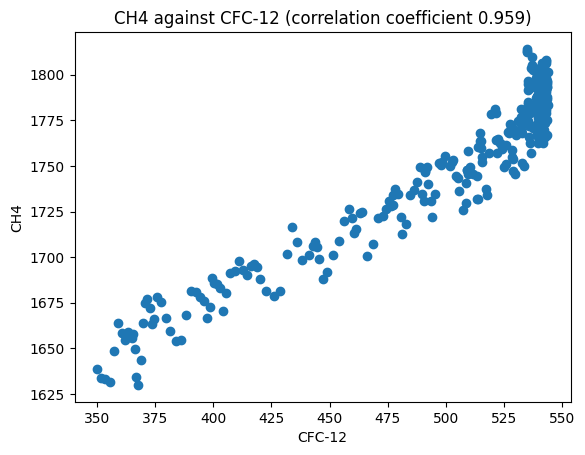

In [350]:
plot_with_coefficient('CFC-12','CH4',dataset_clean_encoded)

There is a very strong positive correlation between CH4 and CFC-12 with a correlation coefficient of 0.959

As CFC-12 levels increase from approximately 350 to 545 parts per trillion, CH4 concentrations rise from about 1625 to 1820 parts per billion

The relationship shows a clear non-linear pattern with increasing slope at higher concentration values

The data points form distinct clusters, particularly at the higher end of the concentration range (CFC-12 > 525)

The graph shows increased variability in CH4 levels as CFC-12 concentrations increase, with more scatter in the data points at higher values

There appears to be a vertical clustering of data points around CFC-12 values of 375-400 and 525-545, suggesting periods where CFC-12 levels stabilized while CH4 continued to vary

Unlike the CFC-11 vs CFC-12 relationship, this graph does not show a decline or loop pattern, indicating CH4 continued to increase even as CFC-12 began to level off

The steeper slope at higher concentration values suggests an accelerating rate of CH4 increase relative to CFC-12 in more recent measurements